In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import mlflow.sklearn

## Data Preparation

**Load the Dataset**

In [2]:
data = pd.read_csv('advertising.csv')

**Data Overview**

In [3]:
data.isnull().sum()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


**Visualize Outliers**

C:\Users\AYA\AppData\Roaming\Python\Python39\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


TV              Axes(0.125,0.53;0.352273x0.35)
radio        Axes(0.547727,0.53;0.352273x0.35)
newspaper       Axes(0.125,0.11;0.352273x0.35)
sales        Axes(0.547727,0.11;0.352273x0.35)
dtype: object

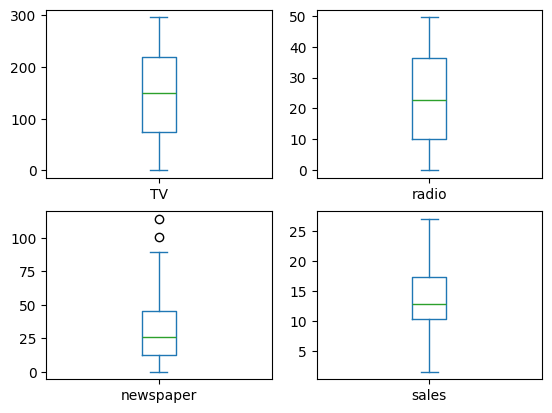

In [4]:
data.plot(kind='box', subplots=True, layout=(2,2), sharex=False, sharey=False)

In [5]:
# remove outlier by clipping
def remove_outlier_clipping(dataframe,lower_quantile,upper_quantile):
    data=dataframe.copy()
    for col in data.columns:
        if data[col].dtype != 'object':
            data[col] = data[col].clip(lower=data[col].quantile(lower_quantile), upper=data[col].quantile(upper_quantile))
    return data

In [6]:
data=remove_outlier_clipping(data,0.05,0.95)

TV              Axes(0.125,0.53;0.352273x0.35)
radio        Axes(0.547727,0.53;0.352273x0.35)
newspaper       Axes(0.125,0.11;0.352273x0.35)
sales        Axes(0.547727,0.11;0.352273x0.35)
dtype: object

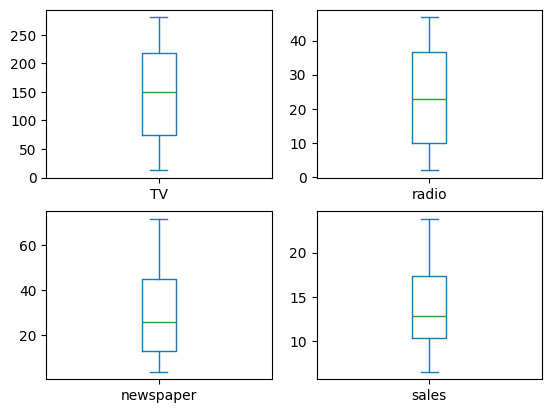

In [7]:
data.plot(kind='box', subplots=True, layout=(2,2), sharex=False, sharey=False)

### Splitting the Dataset

**Define Features & Target**

In [8]:
# Data preparation
X = data.drop(['sales'], axis=1)
y = data['sales']

In [9]:
# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## MLflow Experiment

In [10]:
# Function to train a model and log results in MLflow
def train_and_log_model(model, X_train, y_train, X_val, y_val, model_params, model_name):
    # Train the model
    model.fit(X_train, y_train)

    # Predict on validation set
    predictions = model.predict(X_val)

    # Evaluate the model
    mae = mean_absolute_error(y_val, predictions)
    mse = mean_squared_error(y_val, predictions)
    r2 = r2_score(y_val, predictions)

    # Set experiment and tracking URI for MLflow
    mlflow.set_experiment("Advertising Sales Prediction")
    mlflow.set_tracking_uri("http://127.0.0.1:5000")  # Update if using a different MLflow server

    with mlflow.start_run(run_name=model_name):
        # Log model parameters
        mlflow.log_params(model_params)
        
        # Log evaluation metrics
        mlflow.log_metrics({
            "MAE": mae,
            "MSE": mse,
            "R2": r2
        })

        # Log the model
        mlflow.sklearn.log_model(model, model_name)

# Model training and logging

# 1. Random Forest Regressor
rf_params = {
    "n_estimators": 100,
    "max_depth": 10,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "random_state": 42
}
rf_model = RandomForestRegressor(**rf_params)
train_and_log_model(rf_model, X_train, y_train, X_val, y_val, rf_params, "random_forest_model")

# 2. Gradient Boosting Regressor
gb_params = {
    "n_estimators": 100,
    "learning_rate": 0.01,
    "max_depth": 4,
    "random_state": 42
}
gb_model = GradientBoostingRegressor(**gb_params)
train_and_log_model(gb_model, X_train, y_train, X_val, y_val, gb_params, "gradient_boosting_model")

# 3. Linear Regression
lr_params = {
    "fit_intercept": True
}
lr_model = LinearRegression(**lr_params)
train_and_log_model(lr_model, X_train, y_train, X_val, y_val, lr_params, "linear_regression_model")

# 4. K-Nearest Neighbors Regressor (KNN Regressor)
knn_params = {
    "n_neighbors": 4,
    "weights": 'uniform',
    "algorithm": 'auto'
}
knn_model = KNeighborsRegressor(**knn_params)
train_and_log_model(knn_model, X_train, y_train, X_val, y_val, knn_params, "knn_model")

# 5. Gradient Boosting Regressor (Version 2)
gb_params_v2 = {
    "n_estimators": 100,
    "learning_rate": 0.1,
    "max_depth": 5,
    "random_state": 42
}
gb_model_v2 = GradientBoostingRegressor(**gb_params_v2)
train_and_log_model(gb_model_v2, X_train, y_train, X_val, y_val, gb_params_v2, "gradient_boosting_model_v2")


2025/01/13 21:39:41 INFO mlflow.tracking.fluent: Experiment with name 'Advertising Sales Prediction' does not exist. Creating a new experiment.
2025/01/13 21:39:49 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\AYA\AppData\Local\Temp\tmpvr_3tzpv\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.0.2', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
2025/01/13 21:39:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run random_forest_model at: http://127.0.0.1:5000/#/experiments/875168248403191976/runs/46022b4057a2421db6f4435fd22095a8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/875168248403191976


2025/01/13 21:39:54 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\AYA\AppData\Local\Temp\tmpsfszeil8\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.0.2', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
2025/01/13 21:39:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run gradient_boosting_model at: http://127.0.0.1:5000/#/experiments/875168248403191976/runs/f42cedfd0616406bb1ad37b5d0a4d824
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/875168248403191976


2025/01/13 21:39:58 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\AYA\AppData\Local\Temp\tmp_4i9y_ka\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.0.2', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
2025/01/13 21:39:58 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run linear_regression_model at: http://127.0.0.1:5000/#/experiments/875168248403191976/runs/0aab9a7c41374b5fbdb73597f21b8ed9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/875168248403191976


2025/01/13 21:40:03 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\AYA\AppData\Local\Temp\tmpgh2brpr_\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.0.2', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
2025/01/13 21:40:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run knn_model at: http://127.0.0.1:5000/#/experiments/875168248403191976/runs/63780e3771ec404c94711c8f58dbd777
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/875168248403191976


2025/01/13 21:40:07 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\AYA\AppData\Local\Temp\tmpqcp59fmk\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.0.2', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
2025/01/13 21:40:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run gradient_boosting_model_v2 at: http://127.0.0.1:5000/#/experiments/875168248403191976/runs/131dccb9ec54482298ffeed38c95adb6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/875168248403191976
